# B5 — Regenerate the paper figures (Figures 7, 9, B.1, B.2, graphical abstract)

Each cell rebuilds one figure and **shows it inline + saves it to its output path**.

| Cell | Figure | Saved to |
|---|---|---|
| Fig 7 | LSTM forecast-error boxplot | `outputs/fig7_forecast_error_boxplot.png` |
| Fig 9 | validation-profit learning curves (per-seed, mean±std, seed groups) | `outputs/Fig9_*.png` |
| Fig B.1 | OOD Part A subset selection | `results/ood_analysis/OOD_Subset_Selection.png` |
| Fig B.2 | OOD Part B perturbation examples | `results/ood_analysis/OOD_PartB_Perturbation.png` |
| GA | 2 graphical-abstract charts (+optional pptx) | `outputs/graphical_abstract/ga_*_v2.png` |

The GA chart cell re-evaluates 40 checkpoints and takes 1-3 min; the rest run in seconds.


In [1]:
import os, sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

REV  = os.path.abspath(os.path.join(os.getcwd(), ".."))  # repo root
CODE = os.path.join(REV, "code"); sys.path.insert(0, CODE)
RES  = os.path.join(REV, "results")
ANA  = os.path.join(REV, "outputs")   # paper figures are saved to outputs/


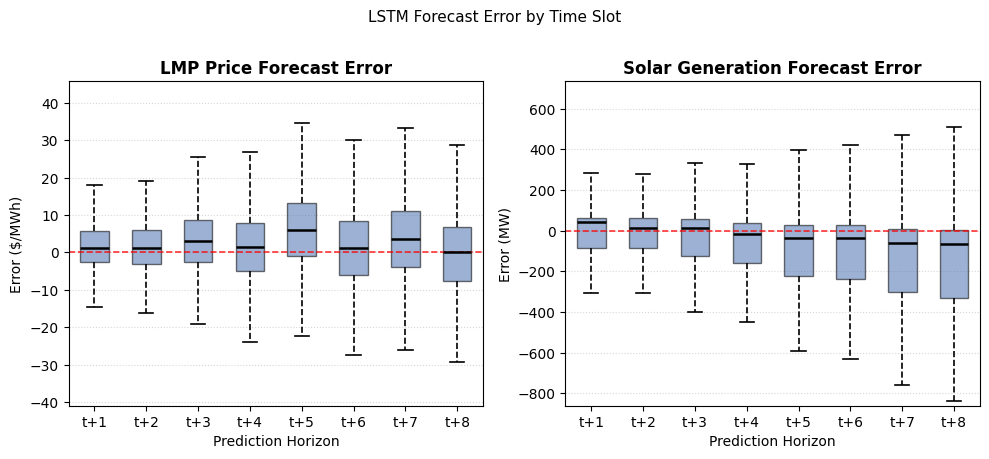

In [2]:
# ── Figure 7: LSTM forecast-error boxplot ────────────────────────────────
FC = os.path.join(RES, "forecast")
price = pd.read_csv(os.path.join(FC, "predictions_LSTM_Price.csv"))
solar = pd.read_csv(os.path.join(FC, "predictions_LSTM_Solar.csv"))
n_steps = 8
price_err = [(price[f"output_{i}"] - price[f"target_{i}"]).values for i in range(1, n_steps + 1)]
solar_err = [(solar[f"output_{i}"] - solar[f"target_{i}"]).values for i in range(1, n_steps + 1)]
labels = [f"t+{i}" for i in range(1, n_steps + 1)]

def iqr_ylim(err_list, k=3.0):
    v = np.concatenate(err_list); q1, q3 = np.percentile(v, 25), np.percentile(v, 75)
    return q1 - k * (q3 - q1), q3 + k * (q3 - q1)

bp_kw = dict(patch_artist=True, showfliers=False, widths=0.55,
             medianprops=dict(color="black", linewidth=1.8),
             boxprops=dict(facecolor="#4C72B0", alpha=0.55),
             whiskerprops=dict(linewidth=1.2, linestyle="--"), capprops=dict(linewidth=1.2))
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, err, ttl, yl in [(axes[0], price_err, "LMP Price Forecast Error", "Error ($/MWh)"),
                         (axes[1], solar_err, "Solar Generation Forecast Error", "Error (MW)")]:
    ax.boxplot(err, tick_labels=labels, **bp_kw)
    ax.axhline(0, color="red", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.set_ylim(*iqr_ylim(err))
    ax.set_title(ttl, fontsize=12, fontweight="bold")
    ax.set_xlabel("Prediction Horizon"); ax.set_ylabel(yl)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.suptitle("LSTM Forecast Error by Time Slot", fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(REV, "outputs", "fig7_forecast_error_boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()


In [3]:
# ── Figure 9 prep: result-json loading helpers ───────────────────────────
BASE = os.path.join(RES, "baseline")
SACQ = os.path.join(RES, "coop_dasac"); MONO = os.path.join(RES, "coop_dabc")
SEEDS = list(range(10))
RL = [("single_sac", "Single-SAC", BASE, 200), ("inde_sac", "Inde-DASAC", BASE, 200),
      ("coop_dasac", "Coop-DASAC", SACQ, 200), ("coop_dabc", "Coop-DABC", MONO, 50)]
def rpath(tag, d, s): return os.path.join(d, f"result_{tag}_deg5.0_tol5.0_seed{s}.json")
def _smooth(a, w):
    if w <= 1: return a
    k = np.ones(w) / w; pad = w // 2
    return np.convolve(np.pad(a, pad, mode="edge"), k, mode="valid")[:len(a)]
SC = list(plt.cm.tab10.colors)


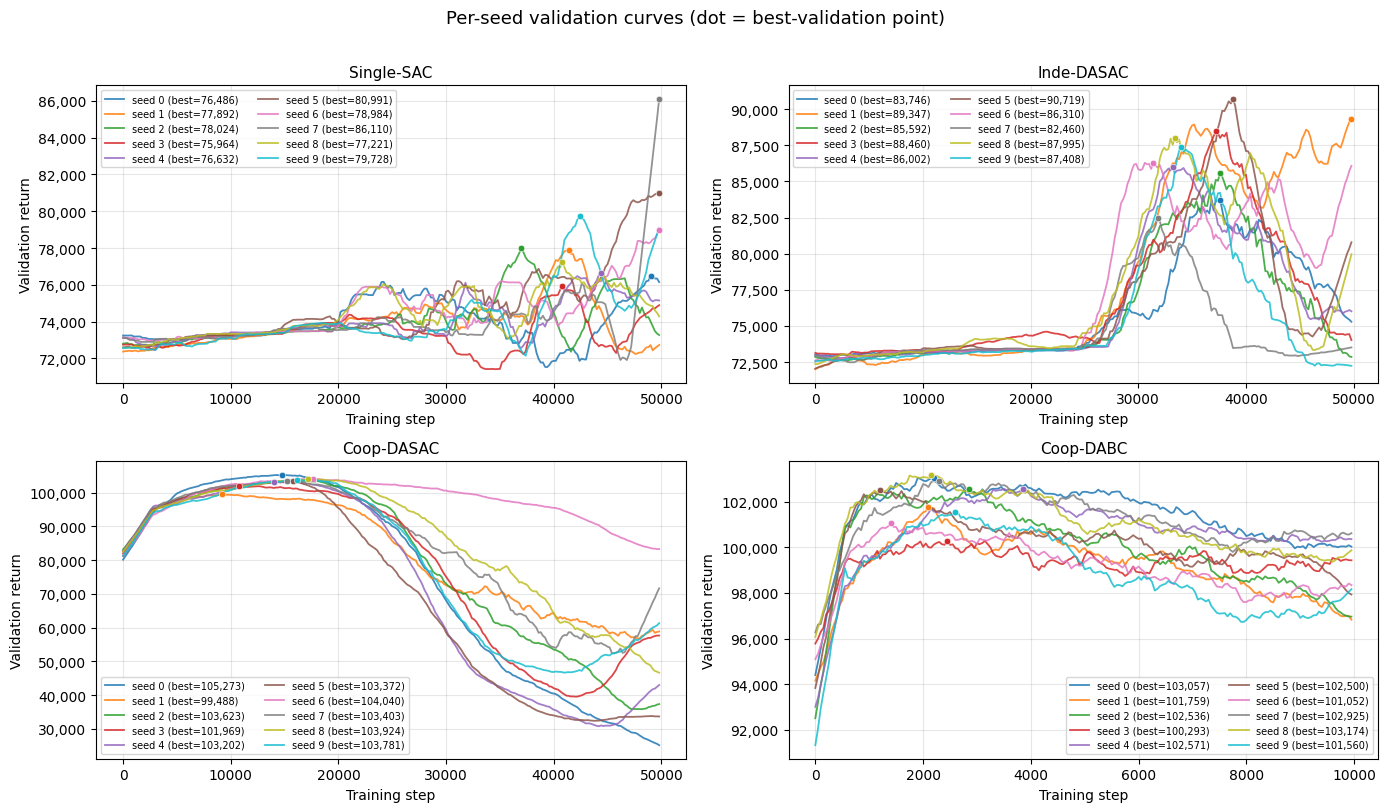

In [4]:
# ── Figure 9a: per-seed validation curves ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (tag, label, d, ef0) in zip(axes.flatten(), RL):
    for s in SEEDS:
        if not os.path.exists(rpath(tag, d, s)): continue
        dd = json.load(open(rpath(tag, d, s))); vr = dd.get("val_returns", [])
        if not vr: continue
        ef = dd.get("eval_freq", ef0); vr = np.array(vr, float)
        vr_s = _smooth(vr, max(1, len(vr) // 10)); steps = np.arange(len(vr)) * ef
        bi = int(np.argmax(vr_s))
        ax.plot(steps, vr_s, lw=1.3, color=SC[s % 10], alpha=0.85,
                label=f"seed {s} (best={vr_s[bi]:,.0f})")
        ax.scatter([steps[bi]], [vr_s[bi]], color=SC[s % 10], s=22, zorder=5,
                   edgecolor="white", linewidth=0.4)
    ax.set_title(label, fontsize=11); ax.set_xlabel("Training step"); ax.set_ylabel("Validation return")
    ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.suptitle("Per-seed validation curves (dot = best-validation point)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ANA, "Fig9_PerSeed_Curves.png"), dpi=150, bbox_inches="tight")
plt.show()


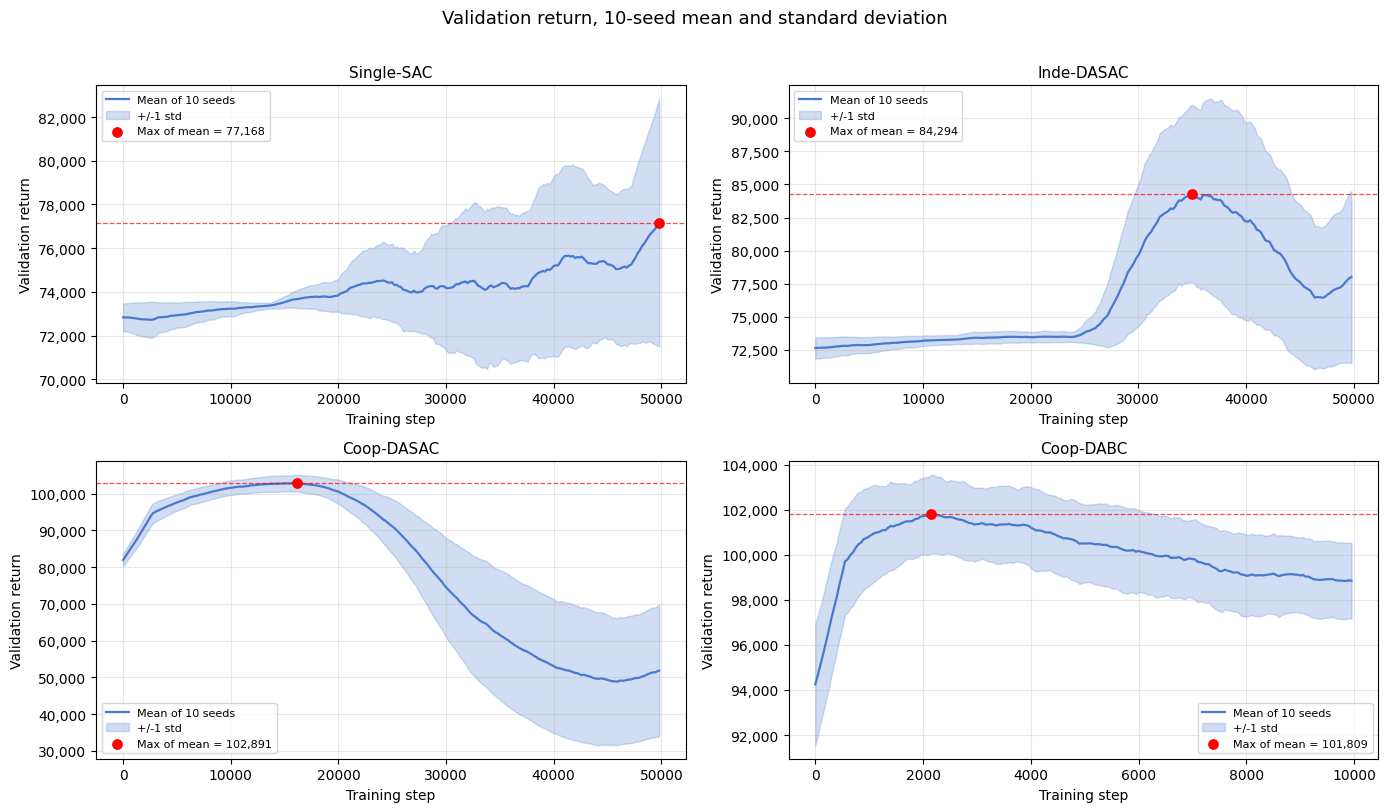

In [5]:
# ── Figure 9b: 10-seed mean ± std ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (tag, label, d, ef0) in zip(axes.flatten(), RL):
    allv = []
    for s in SEEDS:
        if not os.path.exists(rpath(tag, d, s)): continue
        dd = json.load(open(rpath(tag, d, s))); vr = dd.get("val_returns", [])
        if vr: ef0 = dd.get("eval_freq", ef0); allv.append(vr)
    n = min(len(v) for v in allv); arr = np.array([v[:n] for v in allv], float)
    mean, std = arr.mean(0), arr.std(0)
    w = max(1, n // 10); ms, ss = _smooth(mean, w), _smooth(std, w); steps = np.arange(n) * ef0
    pk = int(np.argmax(ms))
    ax.plot(steps, ms, lw=1.6, color="#4878CF", label=f"Mean of {len(allv)} seeds")
    ax.fill_between(steps, ms - ss, ms + ss, alpha=0.25, color="#4878CF", label="+/-1 std")
    ax.axhline(ms[pk], color="red", ls="--", lw=0.9, alpha=0.7)
    ax.scatter([steps[pk]], [ms[pk]], color="red", s=45, zorder=5, label=f"Max of mean = {ms[pk]:,.0f}")
    ax.set_title(label, fontsize=11); ax.set_xlabel("Training step"); ax.set_ylabel("Validation return")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.suptitle("Validation return, 10-seed mean and standard deviation", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ANA, "Fig9_Validation_Curves.png"), dpi=150, bbox_inches="tight")
plt.show()


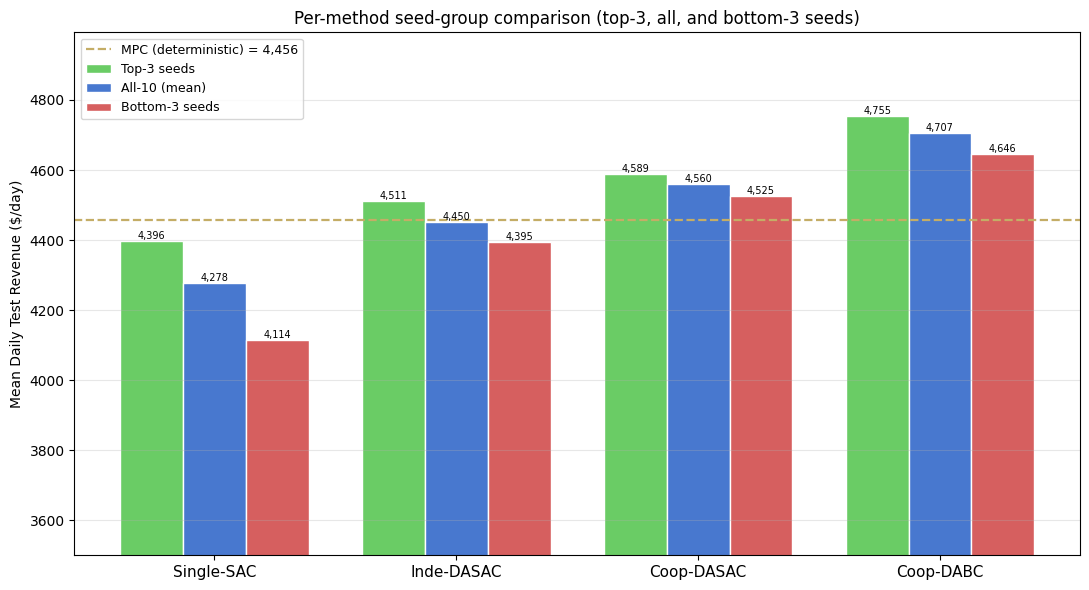

In [6]:
# ── Figure 9c: seed-group comparison (top-3 / all / bottom-3) + MPC line ─
rows = {}
for tag, label, d, _ in RL:
    vals = [json.load(open(rpath(tag, d, s)))["test_mean_total"]
            for s in SEEDS if os.path.exists(rpath(tag, d, s))]
    vals = np.sort(np.array(vals))
    rows[label] = dict(all=vals.mean(), top3=vals[-3:].mean(), bot3=vals[:3].mean(), n=len(vals))
mpc_mean = float(np.array(json.load(open(os.path.join(BASE, "mpc_daily.json"))))[:, 3].mean())
labels = list(rows); x = np.arange(len(labels)); w = 0.26
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - w, [rows[l]["top3"] for l in labels], w, label="Top-3 seeds", color="#6ACC65", edgecolor="white")
ax.bar(x,     [rows[l]["all"]  for l in labels], w, label="All-10 (mean)", color="#4878CF", edgecolor="white")
ax.bar(x + w, [rows[l]["bot3"] for l in labels], w, label="Bottom-3 seeds", color="#D65F5F", edgecolor="white")
ax.axhline(mpc_mean, color="#C4AD66", ls="--", lw=1.6, label=f"MPC (deterministic) = {mpc_mean:,.0f}")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Mean Daily Test Revenue ($/day)"); ax.set_ylim(3500, None)
ax.set_title("Per-method seed-group comparison (top-3, all, and bottom-3 seeds)", fontsize=12)
ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=9)
for i, l in enumerate(labels):
    for xp, key in [(i - w, "top3"), (i, "all"), (i + w, "bot3")]:
        ax.text(xp, rows[l][key], f"{rows[l][key]:,.0f}", ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(ANA, "Fig9_SeedGroup_Comparison.png"), dpi=150, bbox_inches="tight")
plt.show()


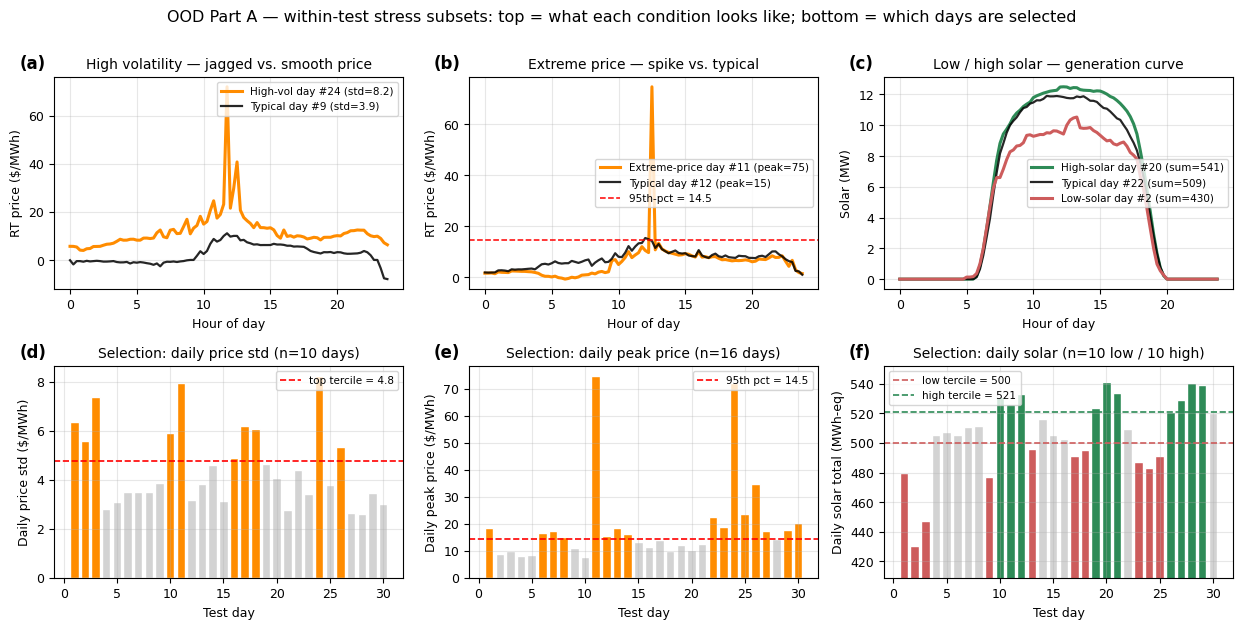

In [7]:
# ── Figure B.1: OOD Part A subset-selection process ──────────────────────
from data.settings import Data_Test
OOD = os.path.join(RES, "ood_analysis")

def _c0(a):
    a = np.asarray(a, dtype=float)
    return a[:, 0] if (a.ndim == 2 and a.shape[1] > 1) else a.reshape(-1)

pd_, sd_ = _c0(Data_Test["Data_Price_Ope"]), _c0(Data_Test["Data_Solar_Ope"])
n_days = len(pd_) // 96
pday = pd_[:n_days * 96].reshape(n_days, 96); sday = sd_[:n_days * 96].reshape(n_days, 96)
day_std, day_solar, day_peak = pday.std(axis=1), sday.sum(axis=1), pday.max(axis=1)
price_95 = np.percentile(pday, 95)
vol_hi, sol_lo, sol_hi = (np.percentile(day_std, 67), np.percentile(day_solar, 33),
                          np.percentile(day_solar, 67))
days = np.arange(1, n_days + 1); hours = np.arange(96) / 4.0
hv, ep = day_std >= vol_hi, (pday > price_95).any(axis=1)
lo, hi = day_solar <= sol_lo, day_solar >= sol_hi
o_v, o_p, o_s = np.argsort(day_std), np.argsort(day_peak), np.argsort(day_solar)
d_vhi, d_vmd = o_v[-1], o_v[len(o_v) // 2]
d_phi, d_pmd = o_p[-1], o_p[len(o_p) // 2]
d_slo, d_shi, d_smd = o_s[0], o_s[-1], o_s[len(o_s) // 2]

plt.rcParams.update({"font.size": 9})
fig, ax = plt.subplots(2, 3, figsize=(12.5, 6.2))
ax[0,0].plot(hours, pday[d_vhi], color="darkorange", lw=2.2, label=f"High-vol day #{d_vhi+1} (std={day_std[d_vhi]:.1f})")
ax[0,0].plot(hours, pday[d_vmd], color="black", lw=1.6, alpha=0.85, label=f"Typical day #{d_vmd+1} (std={day_std[d_vmd]:.1f})")
ax[0,0].set_title("High volatility — jagged vs. smooth price", fontsize=10)
ax[0,1].plot(hours, pday[d_phi], color="darkorange", lw=2.2, label=f"Extreme-price day #{d_phi+1} (peak={day_peak[d_phi]:.0f})")
ax[0,1].plot(hours, pday[d_pmd], color="black", lw=1.6, alpha=0.85, label=f"Typical day #{d_pmd+1} (peak={day_peak[d_pmd]:.0f})")
ax[0,1].axhline(price_95, ls="--", color="red", lw=1.1, label=f"95th-pct = {price_95:.1f}")
ax[0,1].set_title("Extreme price — spike vs. typical", fontsize=10)
ax[0,2].plot(hours, sday[d_shi], color="seagreen", lw=2.2, label=f"High-solar day #{d_shi+1} (sum={day_solar[d_shi]:.0f})")
ax[0,2].plot(hours, sday[d_smd], color="black", lw=1.6, alpha=0.85, label=f"Typical day #{d_smd+1} (sum={day_solar[d_smd]:.0f})")
ax[0,2].plot(hours, sday[d_slo], color="indianred", lw=2.2, label=f"Low-solar day #{d_slo+1} (sum={day_solar[d_slo]:.0f})")
ax[0,2].set_title("Low / high solar — generation curve", fontsize=10)
for a in ax[0]:
    a.set_xlabel("Hour of day"); a.legend(fontsize=7.5)
ax[0,0].set_ylabel("RT price ($/MWh)"); ax[0,1].set_ylabel("RT price ($/MWh)"); ax[0,2].set_ylabel("Solar (MW)")
ax[1,0].bar(days, day_std, color=np.where(hv, "darkorange", "lightgray"), edgecolor="white")
ax[1,0].axhline(vol_hi, ls="--", color="red", lw=1.2, label=f"top tercile = {vol_hi:.1f}")
ax[1,0].set_title(f"Selection: daily price std (n={hv.sum()} days)", fontsize=10); ax[1,0].set_ylabel("Daily price std ($/MWh)")
ax[1,1].bar(days, day_peak, color=np.where(ep, "darkorange", "lightgray"), edgecolor="white")
ax[1,1].axhline(price_95, ls="--", color="red", lw=1.2, label=f"95th pct = {price_95:.1f}")
ax[1,1].set_title(f"Selection: daily peak price (n={ep.sum()} days)", fontsize=10); ax[1,1].set_ylabel("Daily peak price ($/MWh)")
cols = np.where(lo, "indianred", np.where(hi, "seagreen", "lightgray"))
ax[1,2].bar(days, day_solar, color=cols, edgecolor="white")
ax[1,2].axhline(sol_lo, ls="--", color="indianred", lw=1.2, label=f"low tercile = {sol_lo:.0f}")
ax[1,2].axhline(sol_hi, ls="--", color="seagreen", lw=1.2, label=f"high tercile = {sol_hi:.0f}")
ax[1,2].set_ylim(day_solar.min() * 0.95, day_solar.max() * 1.02)
ax[1,2].set_title(f"Selection: daily solar (n={lo.sum()} low / {hi.sum()} high)", fontsize=10); ax[1,2].set_ylabel("Daily solar total (MWh-eq)")
for a in ax[1]:
    a.set_xlabel("Test day"); a.legend(fontsize=7.5)
for i, a in enumerate(ax.flatten()):
    a.grid(alpha=0.3)
    a.text(-0.10, 1.04, f"({chr(97+i)})", transform=a.transAxes, fontsize=12, fontweight="bold")
plt.suptitle("OOD Part A — within-test stress subsets: top = what each condition looks like; "
             "bottom = which days are selected", fontsize=11.5, y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(OOD, "OOD_Subset_Selection.png"), dpi=150, bbox_inches="tight")
plt.show()


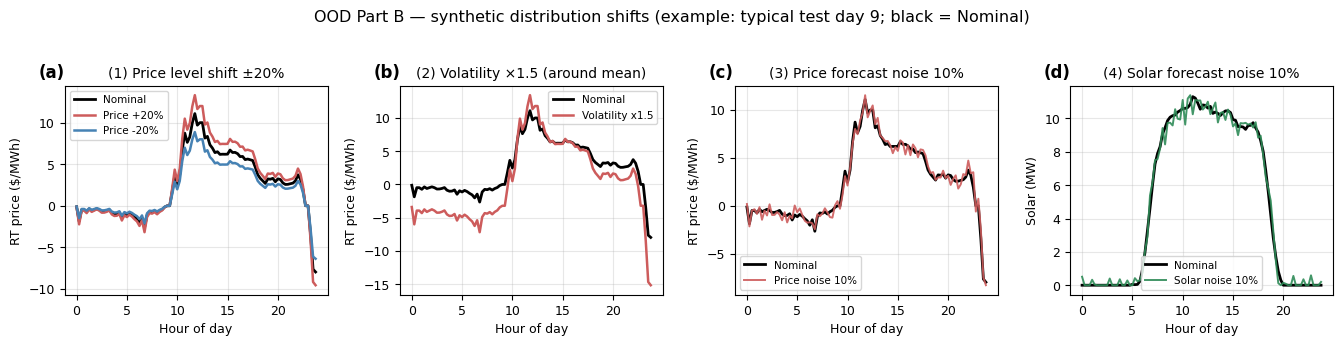

In [8]:
# ── Figure B.2: OOD Part B perturbation examples ─────────────────────────
from algorithms.eval_utils import perturb_data
_dstd = pday.std(axis=1)
D = int(np.argsort(_dstd)[n_days // 2]); sl = slice(D * 96, (D + 1) * 96)
p_nom, s_nom = pd_[sl], sd_[sl]
def pmod(kw): return _c0(perturb_data(Data_Test, **kw)["Data_Price_Ope"])[sl]
def smod(kw): return _c0(perturb_data(Data_Test, **kw)["Data_Solar_Ope"])[sl]

fig, ax = plt.subplots(1, 4, figsize=(13.5, 3.3))
ax[0].plot(hours, p_nom, color="black", lw=2, label="Nominal")
ax[0].plot(hours, pmod(dict(price_scale=1.2)), color="indianred", lw=1.8, label="Price +20%")
ax[0].plot(hours, pmod(dict(price_scale=0.8)), color="steelblue", lw=1.8, label="Price -20%")
ax[0].set_title("(1) Price level shift ±20%", fontsize=10)
ax[1].plot(hours, p_nom, color="black", lw=2, label="Nominal")
ax[1].plot(hours, pmod(dict(vol_scale=1.5)), color="indianred", lw=1.8, label="Volatility x1.5")
ax[1].set_title("(2) Volatility ×1.5 (around mean)", fontsize=10)
ax[2].plot(hours, p_nom, color="black", lw=2, label="Nominal")
ax[2].plot(hours, pmod(dict(price_noise=0.10)), color="indianred", lw=1.4, alpha=0.9, label="Price noise 10%")
ax[2].set_title("(3) Price forecast noise 10%", fontsize=10)
ax[3].plot(hours, s_nom, color="black", lw=2, label="Nominal")
ax[3].plot(hours, smod(dict(solar_noise=0.10)), color="seagreen", lw=1.4, alpha=0.9, label="Solar noise 10%")
ax[3].set_title("(4) Solar forecast noise 10%", fontsize=10)
for i, a in enumerate(ax):
    a.set_xlabel("Hour of day"); a.grid(alpha=0.3); a.legend(fontsize=7.5)
    a.set_ylabel("Solar (MW)" if i == 3 else "RT price ($/MWh)")
    a.text(-0.10, 1.04, f"({chr(97+i)})", transform=a.transAxes, fontsize=12, fontweight="bold")
plt.suptitle(f"OOD Part B — synthetic distribution shifts (example: typical test day {D+1}; black = Nominal)",
             fontsize=11.5, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OOD, "OOD_PartB_Perturbation.png"), dpi=150, bbox_inches="tight")
plt.show()


Single-SAC   mean=4,261  day-std=1,746  n=10


Inde-DASAC   mean=4,455  day-std=1,687  n=10


Coop-DASAC   mean=4,566  day-std=1,600  n=10


Coop-DABC    mean=4,707  day-std=1,868  n=10


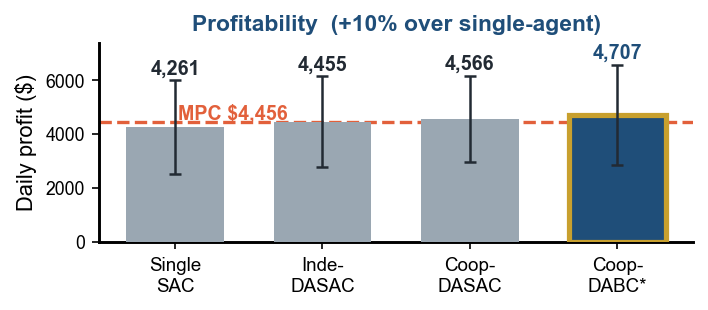

In [9]:
# ── GA chart 1: profit comparison (re-evaluates 40 checkpoints, 1-3 min) ─
from data.settings import Data_Test
from algorithms.eval_utils import METHODS, set_cap_ope, make_envs, find_ckpt, evaluate_checkpoint

plt.rcParams.update({"font.family": "Arial", "font.size": 16, "axes.linewidth": 1.4})
C_DA, C_RT, C_ESS = "#1F4E79", "#E2603B", "#2E9E8F"
C_GOLD, C_GRAY, C_TEXT = "#C8A02E", "#9AA7B2", "#222A33"
GA = os.path.join(ANA, "graphical_abstract"); os.makedirs(GA, exist_ok=True)

set_cap_ope(5.0)
env_d, env_s = make_envs(Data_Test, 5.0, 5.0)
ORDER = [("Single\nSAC", "Single-SAC"), ("Inde-\nDASAC", "Inde-DASAC"),
         ("Coop-\nDASAC", "Coop-DASAC"), ("Coop-\nDABC*", "Coop-DABC")]
vals, errs, labels = [], [], []
for lab, name in ORDER:
    spec = METHODS[name]; ms, ss = [], []
    for s in range(10):
        p = find_ckpt(spec["dirs"], spec["tag"], 5.0, 5.0, s)
        if p is None: continue
        d = evaluate_checkpoint(spec["kind"], p, env_d, env_s)[:, 3]
        ms.append(d.mean()); ss.append(d.std())
    vals.append(np.mean(ms)); errs.append(np.mean(ss)); labels.append(lab)
    print(f"{name:<12} mean={vals[-1]:,.0f}  day-std={errs[-1]:,.0f}  n={len(ms)}")
mpc = np.mean([r[3] for r in json.load(open(os.path.join(RES, "baseline", "mpc_daily.json")))])

fig, ax = plt.subplots(figsize=(5.0, 2.35), dpi=150)
colors = [C_GRAY, C_GRAY, C_GRAY, C_DA]; edges = ["none", "none", "none", C_GOLD]
x = np.arange(len(vals))
ax.bar(x, vals, width=0.66, color=colors, edgecolor=edges, linewidth=2.5, zorder=3)
ax.errorbar(x, vals, yerr=errs, fmt="none", ecolor=C_TEXT, elinewidth=1.2, capsize=3, capthick=1.2, zorder=4)
ax.axhline(mpc, ls="--", lw=1.6, color=C_RT, zorder=2)
ax.text(0.02, mpc + 90, f"MPC ${mpc:,.0f}", color=C_RT, fontsize=9.5, fontweight="bold")
for xi, v in zip(x, vals):
    ax.text(xi, v + errs[int(xi)] + 80, f"{v:,.0f}", ha="center", va="bottom", fontsize=9.5,
            fontweight="bold", color=C_DA if xi == 3 else C_TEXT)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Daily profit ($)", fontsize=10.5); ax.set_ylim(0, max(vals) + max(errs) + 800)
ax.spines[["top", "right"]].set_visible(False); ax.tick_params(axis="y", labelsize=8.5)
ax.set_title(f"Profitability  (+{(vals[3]/vals[0]-1)*100:.0f}% over single-agent)",
             fontsize=11, fontweight="bold", color=C_DA, pad=6)
fig.tight_layout()
fig.savefig(os.path.join(GA, "ga_profit_compact_v2.png"), transparent=True, dpi=300, bbox_inches="tight")
plt.show()


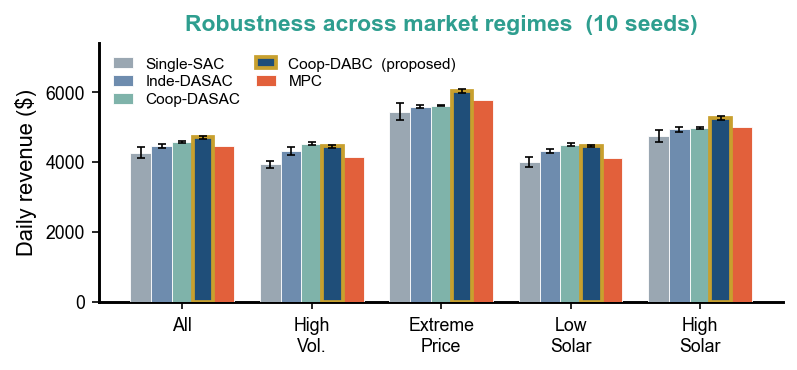

In [10]:
# ── GA chart 2: robustness by market condition (uses B3's CSVs) ──────────
ood = pd.read_csv(os.path.join(RES, "ood_analysis", "OOD_Compare_PartA_mono.csv"))
ood["Method"] = ood["Method"].replace({"Coop-SAC": "Coop-DASAC"})   # legacy CSV compatibility
subsets5 = ["All Test Days", "High Volatility", "Extreme Price", "Low Solar", "High Solar"]
xlab = ["All", "High\nVol.", "Extreme\nPrice", "Low\nSolar", "High\nSolar"]
methods = [("Single-SAC", C_GRAY), ("Inde-DASAC", "#6E8CAE"), ("Coop-DASAC", "#7FB3AA"),
           ("Coop-DABC", C_DA), ("MPC", C_RT)]
xpos = np.arange(len(subsets5)); n_m = len(methods); width = 0.16
fig, ax = plt.subplots(figsize=(5.6, 2.75), dpi=150)
for i, (name, col) in enumerate(methods):
    sub = ood[ood["Method"] == name].set_index("Subset").loc[subsets5]
    off = (i - (n_m - 1) / 2) * width; is_prop = name == "Coop-DABC"
    ax.bar(xpos + off, sub["mean"].values, width, color=col,
           edgecolor=C_GOLD if is_prop else "white", linewidth=1.8 if is_prop else 0.4,
           yerr=None if name == "MPC" else sub["std"].values, capsize=2,
           error_kw=dict(elinewidth=0.8, capthick=0.8),
           label=name + ("  (proposed)" if is_prop else ""), zorder=4 if is_prop else 3)
ax.set_xticks(xpos); ax.set_xticklabels(xlab, fontsize=8.5)
ax.set_ylabel("Daily revenue ($)", fontsize=10.5); ax.set_ylim(0, 7400)
ax.tick_params(axis="y", labelsize=8.5); ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Robustness across market regimes  (10 seeds)", fontsize=11, fontweight="bold", color=C_ESS, pad=6)
ax.legend(frameon=False, fontsize=7.4, ncol=2, loc="upper left", handlelength=1.3,
          columnspacing=1.0, labelspacing=0.25)
fig.tight_layout()
fig.savefig(os.path.join(GA, "ga_robustness_v2.png"), transparent=True, dpi=300, bbox_inches="tight")
plt.show()
plt.rcParams.update(plt.rcParamsDefault)   # restore font settings


In [11]:
# ── (optional) bundle both charts into a pptx for the graphical abstract ─
MAKE_PPTX = False   # set True to write outputs/graphical_abstract/graphical_abstract_charts_v2.pptx
if MAKE_PPTX:
    from pptx import Presentation
    from pptx.util import Inches, Pt
    prs = Presentation(); prs.slide_width = Inches(13.333); prs.slide_height = Inches(7.5)
    s = prs.slides.add_slide(prs.slide_layouts[6])
    tb = s.shapes.add_textbox(Inches(0.4), Inches(0.15), Inches(12), Inches(0.5))
    tb.text_frame.text = "Corrected charts (eval-mode, 10 seeds) - copy & paste into Graphical_Abstract.pptx"
    s.shapes.add_picture(os.path.join(GA, "ga_profit_compact_v2.png"), Inches(0.4), Inches(1.0), width=Inches(5.8))
    s.shapes.add_picture(os.path.join(GA, "ga_robustness_v2.png"), Inches(6.6), Inches(1.0), width=Inches(6.3))
    out = os.path.join(GA, "graphical_abstract_charts_v2.pptx")
    prs.save(out); print("saved:", out)
